In [1]:
import pandas as pd

In [2]:
nyc = pd.read_csv("ave_hi_nyc_jan_1895-2018.csv")

In [3]:
nyc.columns=['Date', 'Temperature', 'Anomaly']

In [4]:
nyc.Date = nyc.Date.floordiv(100)

In [5]:
nyc

,Date,Temperature,Anomaly
0,1895,34.2,-3.2
1,1896,34.7,-2.7
2,1897,35.5,-1.9
3,1898,39.6,2.2
4,1899,36.4,-1.0
...,...,...,...
119,2014,35.5,-1.9
120,2015,36.1,-1.3
121,2016,40.8,3.4
122,2017,42.8,5.4


In [6]:
#LinearRegression estimator from sklear.linear_model

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    nyc.Date.values.reshape(-1,1), #Returns the Date column's Series, then return (with values attribute) Numpy Array containing that Series' value
                                    #with -1 tells reshape to infer the number of rows based on the number of columns (1) and the number of elements in the array
    nyc.Temperature.values,        #
    random_state=11
)

In [9]:
X_train.shape

(93, 1)

In [10]:
X_test.shape

(31, 1)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
linear_regression = LinearRegression()

In [15]:
linear_regression.fit(X=X_train, y=y_train)         #Returns the estimator

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
linear_regression.coef_             #in formula y = mx + b, coef is m

array([0.01939167])

In [17]:
linear_regression.intercept_    #in formula y = mx + b, intercept is b

np.float64(-0.30779820252656975)

In [19]:
predicted = linear_regression.predict(X_test)

In [20]:
expected = y_test

In [21]:
for p, e in zip(predicted[::5], expected[::5]):
    print(f'Predicted: {p:.2f}, Expected: {e:.2f}')

Predicted: 37.86, Expected: 31.70
Predicted: 38.69, Expected: 34.80
Predicted: 37.00, Expected: 39.40
Predicted: 37.25, Expected: 45.70
Predicted: 38.05, Expected: 32.30
Predicted: 37.64, Expected: 33.80
Predicted: 36.94, Expected: 39.70


In [22]:
#Predict temperature in 2019 y 1890 january, using y = mx + b

In [23]:
predict = (lambda x: linear_regression.coef_*x + linear_regression.intercept_)

In [24]:
predict(2019)

array([38.84399018])

In [26]:
predict(1890)

array([36.34246432])

In [44]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [45]:
#Visualizing the Dataset with the Regression Line

In [46]:
import seaborn as sns

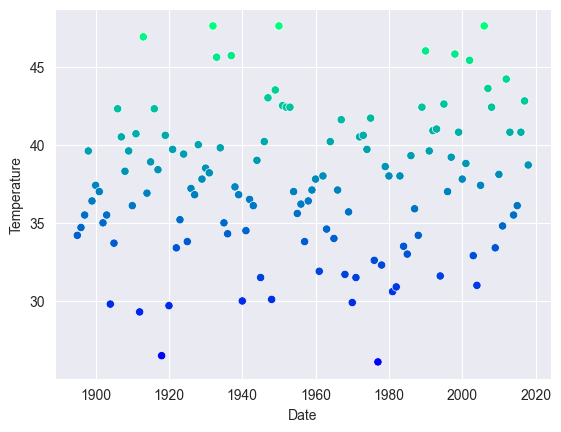

In [62]:
axes = sns.scatterplot(data = nyc, x='Date', y='Temperature', hue='Temperature', palette='winter', legend=False)

In [48]:
#data -> specifies the DataFrame containing the data to display
#x, y -> source of the data along the x- and y-axes
#hue -> specifies wich column's data should be used to determine the dot colors.
#palette -> specifies a Matplotlib color map from which to choose the dots' colors
#legend -> specifies that scatterplot should not show a legend for the grapg

In [49]:
axes.set_ylim(10, 70)

(10.0, 70.0)

In [50]:
#Determine the x-coordinates of the regression line's start and end point

In [51]:
import numpy as np

In [52]:
x = np.array([min(nyc.Date.values), max(nyc.Date.values)])

In [53]:
x

array([1895, 2018])

In [54]:
y = predict(x)

In [55]:
y

array([36.43942269, 38.82459851])

In [56]:
import matplotlib.pyplot as plt

(10.0, 70.0)

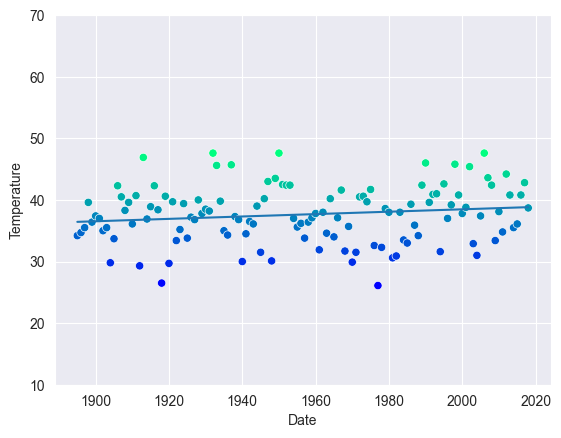

In [68]:
line = plt.plot(x,y)
axes = sns.scatterplot(data = nyc, x='Date', y='Temperature', hue='Temperature', palette='winter', legend=False)
axes.set_ylim(10, 70)
